In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("healthcare-dataset-stroke-data pandas.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [5]:
df1=df[df.isnull().any(axis=1)]

In [6]:
pd.options.display.max_rows = 210

In [7]:
df1=df.nlargest(5500,"age")

In [8]:
df1.infer_objects(copy=False)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3108,53252,Male,82.00,0,0,No,Self-employed,Urban,161.95,30.8,never smoked,0
188,30184,Male,82.00,0,0,Yes,Private,Rural,86.62,29.5,formerly smoked,1
1515,72474,Female,82.00,0,0,Yes,Govt_job,Rural,58.30,20.4,never smoked,0
1412,62452,Male,82.00,1,0,Yes,Private,Rural,227.28,33.3,never smoked,0
1951,1460,Female,82.00,0,0,Yes,Private,Urban,99.68,22.2,Unknown,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3618,22877,Male,0.16,0,0,No,children,Urban,114.71,17.4,Unknown,0
3968,41500,Male,0.16,0,0,No,children,Rural,69.79,13.0,Unknown,0
4021,8247,Male,0.16,0,0,No,children,Urban,109.52,13.9,Unknown,0
1614,47350,Female,0.08,0,0,No,children,Urban,139.67,14.1,Unknown,0


In [9]:
df2 = df1.sort_values(by=['age','avg_glucose_level'], ascending=[False,False])

In [10]:
df3=df2.round(0)
df3=df3.convert_dtypes()

In [11]:
s=(df3.map(type))
h=s.nunique()

In [12]:
inter=df3.copy()

In [13]:
inter = inter.drop(inter.columns[[0, 1,3,4,5,6,7,10,11]], axis=1)

In [14]:
inter=inter.infer_objects()

In [15]:
inter=inter.interpolate(method="linear")

In [16]:
print(inter.to_string())

       age  avg_glucose_level        bmi
1529  82.0              253.0       48.0
2633  82.0              244.0       24.0
2418  82.0              230.0       24.0
3360  82.0              229.0       28.0
1412  82.0              227.0       33.0
3637  82.0              227.0       25.0
4164  82.0              223.0       29.5
4763  82.0              218.0       34.0
187   82.0              216.0       28.0
337   82.0              216.0       25.0
3462  82.0              215.0       24.0
2453  82.0              214.0       34.0
1769  82.0              212.0       29.0
5062  82.0              212.0       37.0
23    82.0              208.0       32.0
128   82.0              201.0       29.0
32    82.0              197.0       22.0
3108  82.0              162.0       31.0
42    82.0              145.0       26.0
1691  82.0              144.0       35.0
2275  82.0              118.0       30.0
4452  82.0              116.0       31.0
4819  82.0              113.0       30.0
4094  82.0      

In [17]:
inter.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5110 entries, 1529 to 3295
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                5110 non-null   Float64
 1   avg_glucose_level  5110 non-null   Float64
 2   bmi                5110 non-null   Float64
dtypes: Float64(3)
memory usage: 174.7 KB


In [18]:
inter = inter.drop(inter.columns[[0, 1]], axis=1)

In [19]:
cleaned=df3.combine_first(inter)

In [20]:
cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5110 entries, 1529 to 3295
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Residence_type     5110 non-null   string 
 1   age                5110 non-null   Int64  
 2   avg_glucose_level  5110 non-null   Int64  
 3   bmi                5110 non-null   Float64
 4   ever_married       5110 non-null   string 
 5   gender             5110 non-null   string 
 6   heart_disease      5110 non-null   Int64  
 7   hypertension       5110 non-null   Int64  
 8   id                 5110 non-null   Int64  
 9   smoking_status     5110 non-null   string 
 10  stroke             5110 non-null   Int64  
 11  work_type          5110 non-null   string 
dtypes: Float64(1), Int64(6), string(5)
memory usage: 553.9 KB


In [21]:
cleaned.to_csv("bona.csv",index=False)

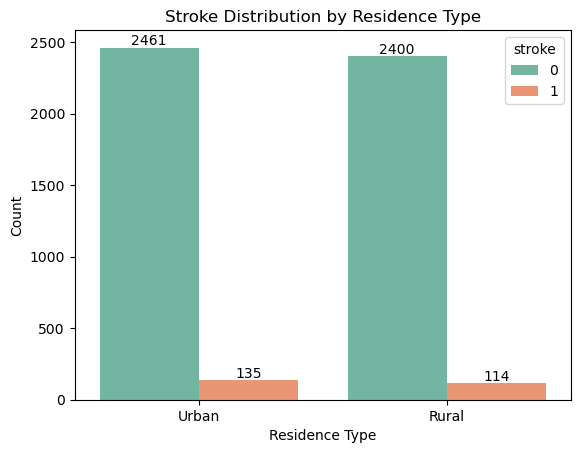

In [31]:
ax = sns.countplot(data=df, x="Residence_type", hue="stroke", palette="Set2")
ax.set_title("Stroke Distribution by Residence Type")
ax.set_xlabel("Residence Type")
ax.set_ylabel("Count")

# Add bar labels using containers
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.show()

# Residence Type vs Stroke 

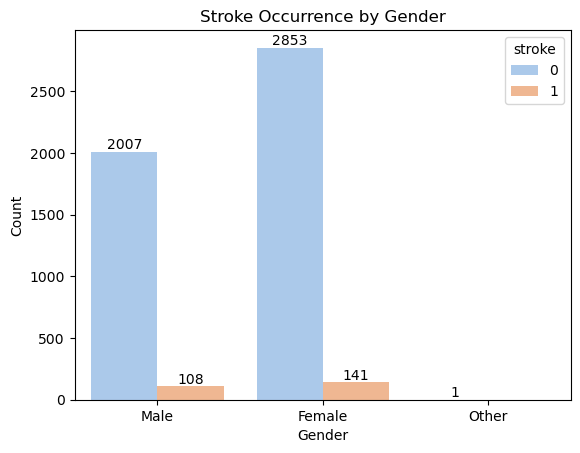

In [32]:
ax = sns.countplot(data=df, x="gender", hue="stroke", palette="pastel")
ax.set_title("Stroke Occurrence by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Count")

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.show()
# Gender and Stroke distribution 

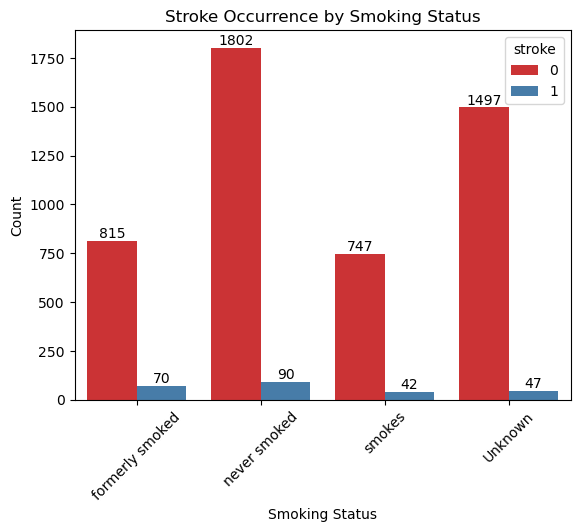

In [33]:
ax = sns.countplot(data=df, x="smoking_status", hue="stroke", palette="Set1")
ax.set_title("Stroke Occurrence by Smoking Status")
ax.set_xlabel("Smoking Status")
ax.set_ylabel("Count")
plt.xticks(rotation=45)

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.show()
# Smoking vs Stroke distribution

C:\Users\Student\AppData\Local\Temp\ipykernel_25000\3733132870.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x="stroke", y="avg_glucose_level", palette="coolwarm")


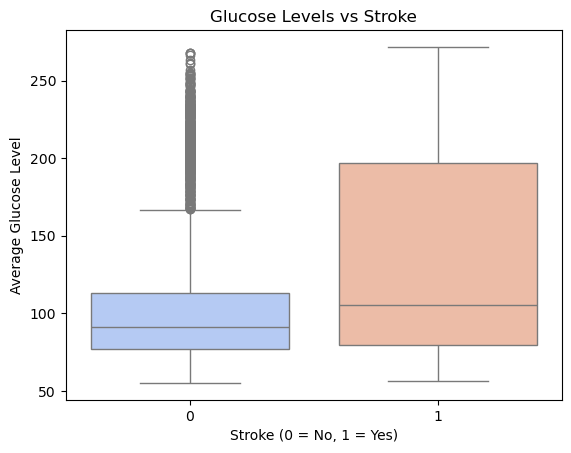

In [34]:
ax = sns.boxplot(data=df, x="stroke", y="avg_glucose_level", palette="coolwarm")
ax.set_title("Glucose Levels vs Stroke")
ax.set_xlabel("Stroke (0 = No, 1 = Yes)")
ax.set_ylabel("Average Glucose Level")
plt.show()
# Glucose level vs Stroke Dstributions 

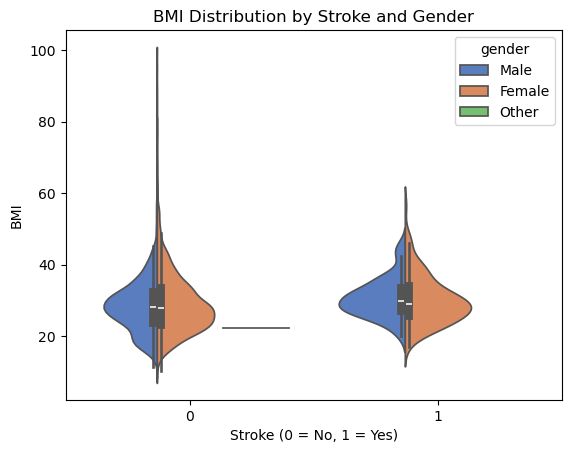

In [35]:
ax = sns.violinplot(data=df, x="stroke", y="bmi", hue="gender", split=True, palette="muted")
ax.set_title("BMI Distribution by Stroke and Gender")
ax.set_xlabel("Stroke (0 = No, 1 = Yes)")
ax.set_ylabel("BMI")
plt.show()
# BMI vs Stroke Distribution 

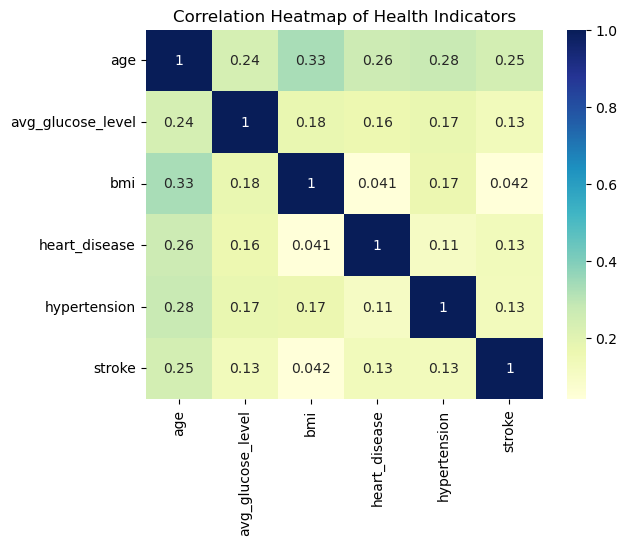

In [36]:
corr = df[["age","avg_glucose_level","bmi","heart_disease","hypertension","stroke"]].corr()
ax = sns.heatmap(corr, annot=True, cmap="YlGnBu")
ax.set_title("Correlation Heatmap of Health Indicators")
plt.show()
# Corelation Heat Map 

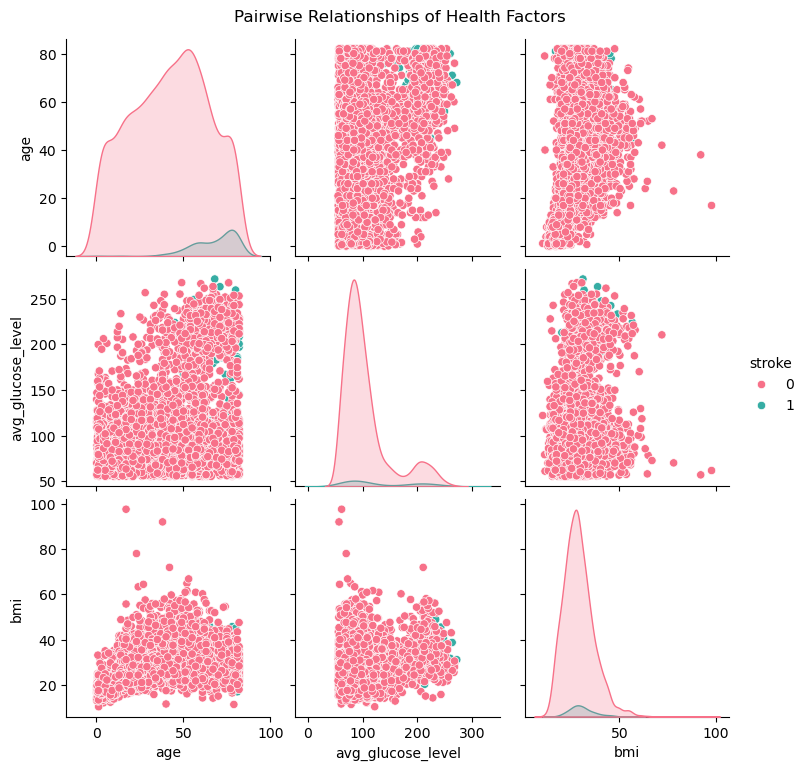

In [37]:
sns.pairplot(df[["age","avg_glucose_level","bmi","stroke"]], hue="stroke", palette="husl")
plt.suptitle("Pairwise Relationships of Health Factors", y=1.02)
plt.show()
# Pair Wise Relationship 

In [ ]:
 build a summary dashboard that combines multiple Seaborn plots into one figure, so you can visually compare stroke shares across demographics and risk factors in a single glance:

python
import seaborn as sns
import matplotlib.pyplot as plt

# Set style for consistency
sns.set_style("whitegrid")
sns.set_context("talk")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Residence Type vs Stroke
ax1 = sns.countplot(data=df, x="Residence_type", hue="stroke", palette="Set2", ax=axes[0,0])
ax1.set_title("Stroke Share by Residence Type")
ax1.set_xlabel("Residence Type")
ax1.set_ylabel("Count")
for container in ax1.containers:
    ax1.bar_label(container, labels=[f'{(p.get_height()/len(df)*100):.1f}%' for p in container])

# 2. Gender vs Stroke
ax2 = sns.countplot(data=df, x="gender", hue="stroke", palette="pastel", ax=axes[0,1])
ax2.set_title("Stroke Share by Gender")
ax2.set_xlabel("Gender")
ax2.set_ylabel("Count")
for container in ax2.containers:
    ax2.bar_label(container, labels=[f'{(p.get_height()/len(df)*100):.1f}%' for p in container])

# 3. Smoking Status vs Stroke
ax3 = sns.countplot(data=df, x="smoking_status", hue="stroke", palette="Set1", ax=axes[1,0])
ax3.set_title("Stroke Share by Smoking Status")
ax3.set_xlabel("Smoking Status")
ax3.set_ylabel("Count")
ax3.tick_params(axis='x', rotation=45)
for container in ax3.containers:
    ax3.bar_label(container, labels=[f'{(p.get_height()/len(df)*100):.1f}%' for p in container])

# 4. Work Type vs Stroke
ax4 = sns.countplot(data=df, x="work_type", hue="stroke", palette="husl", ax=axes[1,1])
ax4.set_title("Stroke Share by Work Type")
ax4.set_xlabel("Work Type")
ax4.set_ylabel("Count")
ax4.tick_params(axis='x', rotation=45)
for container in ax4.containers:
    ax4.bar_label(container, labels=[f'{(p.get_height()/len(df)*100):.1f}%' for p in container])

plt.tight_layout()